In [1]:
# Librerias
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers, optimizers, metrics
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image



from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
print("Dispositivo:", tf.test.gpu_device_name())

Dispositivo: /device:GPU:0


In [3]:
print("GPUs detectadas:", tf.config.list_physical_devices('GPU'))
print("Ejecución en GPU:", tf.test.is_built_with_cuda())
print("Dispositivo:", tf.test.gpu_device_name())


GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Ejecución en GPU: True
Dispositivo: /device:GPU:0


In [4]:
# Directorios
train_dir = "../data/lesions/train"
test_dir = "../data/lesions/test" 

In [27]:
# Reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
color_train = "#5FAA3F"  
color_val = "#984bb7" 

# Importar y Redimensionar Máscaras

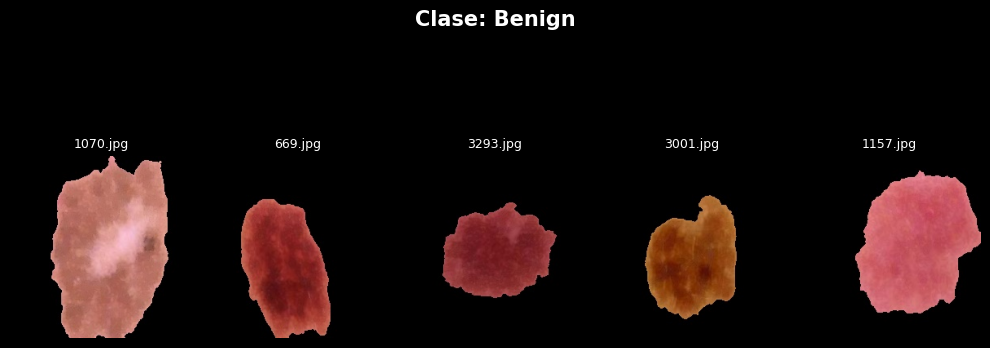

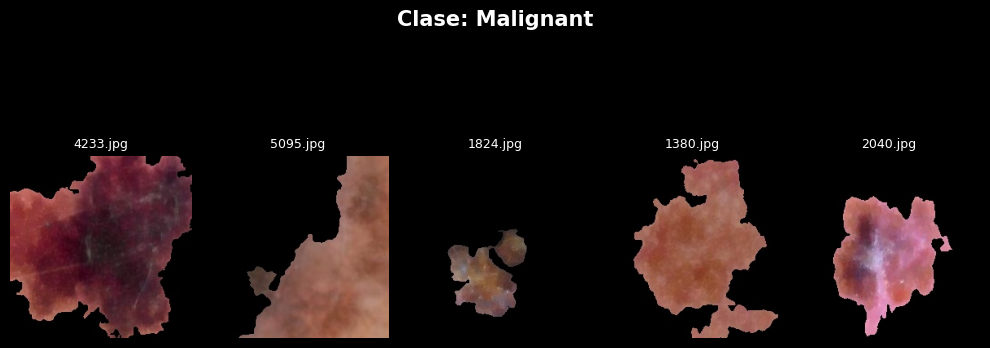

In [8]:
def mostrar_imagenes_random(carpeta, clase=None, n=5):
    if clase:
        carpeta = os.path.join(carpeta, clase)

    archivos = random.sample(os.listdir(carpeta), n)

    fig, axes = plt.subplots(1, n, figsize=(10, 4), facecolor='black')
    fig.suptitle(f"Clase: {clase}", fontsize=15, fontweight='bold', y=1.05, color='white')

    for ax, img_name in zip(axes, archivos):
        img = cv2.imread(os.path.join(carpeta, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_name, fontsize=9, color='white')
        ax.axis('off')
        ax.set_facecolor('black')  # fondo negro también para los ejes

    plt.subplots_adjust(top=0.8, wspace=0.05)  # red
    plt.tight_layout()
    plt.show()


# Ejemplo de uso
mostrar_imagenes_random(train_dir, "Benign", 5)
mostrar_imagenes_random(train_dir, "Malignant", 5)

### Normalización y Reescalado 

In [9]:
ROWS, COLS = 224, 224
BATCH= 32

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [11]:
train_gen = train_datagen.flow_from_directory(
    directory=train_dir,
    class_mode='categorical',      # 2 clases: Benign / Malignant
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    directory=test_dir,
    class_mode='categorical',
    batch_size=BATCH,
    target_size=(ROWS, COLS),
    color_mode='rgb',
    shuffle=False,
    seed=SEED
)

Found 11879 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# Modelo

In [12]:
ROWS, COLS = 224, 224
input_shape = (ROWS, COLS, 3)


inputs = layers.Input(shape=input_shape)

# Bloque 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name="conv1")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# Bloque 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same', name="conv2")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.25)(x)

# Bloque 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name="conv3")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.3)(x)

# Clasificación
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name="dense1")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(2, activation='softmax', name="output")(x)

In [13]:
modelo1 = tf.keras.Model(inputs=inputs, outputs=outputs, name="MelanomaNet")

In [14]:
modelo1.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall')
    ]
)

In [15]:
history_1= modelo1.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30,

)

Epoch 1/30
372/372 [==============================] - 167s 71ms/step - loss: 0.7016 - accuracy: 0.7470 - precision: 0.7470 - recall: 0.7470 - val_loss: 3.2823 - val_accuracy: 0.5025 - val_precision: 0.5025 - val_recall: 0.5025
Epoch 2/30
372/372 [==============================] - 25s 68ms/step - loss: 0.5468 - accuracy: 0.7985 - precision: 0.7985 - recall: 0.7985 - val_loss: 2.0991 - val_accuracy: 0.6790 - val_precision: 0.6790 - val_recall: 0.6790
Epoch 3/30
372/372 [==============================] - 26s 69ms/step - loss: 0.4900 - accuracy: 0.8143 - precision: 0.8143 - recall: 0.8143 - val_loss: 1.0060 - val_accuracy: 0.7955 - val_precision: 0.7955 - val_recall: 0.7955
Epoch 4/30
372/372 [==============================] - 26s 70ms/step - loss: 0.4724 - accuracy: 0.8219 - precision: 0.8219 - recall: 0.8219 - val_loss: 4.3670 - val_accuracy: 0.7320 - val_precision: 0.7320 - val_recall: 0.7320
Epoch 5/30
372/372 [==============================] - 26s 69ms/step - loss: 0.4290 - accuracy: 

# Evaluación Modelo

## Curvas Train Vs Val

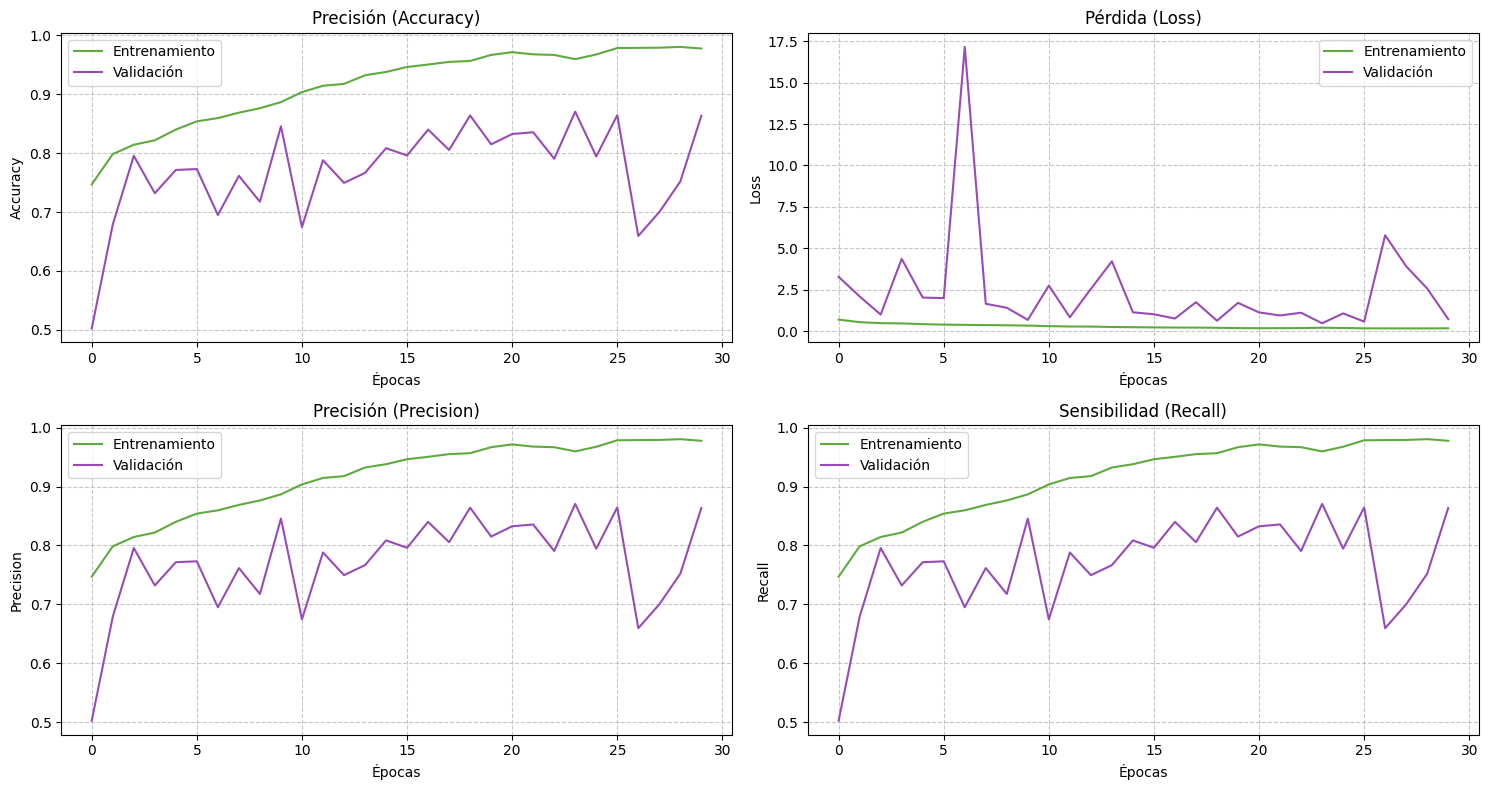

In [16]:
plt.figure(figsize=(15, 8))

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history_1.history['accuracy'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], color=color_val, label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss
plt.subplot(2, 2, 2)
plt.plot(history_1.history['loss'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_loss'], color=color_val, label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Precision (si definiste precision en metrics del modelo)
plt.subplot(2, 2, 3)
plt.plot(history_1.history['precision'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_precision'], color=color_val, label='Validación')
plt.title('Precisión (Precision)')
plt.xlabel('Épocas')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Recall (si definiste recall en metrics del modelo)
plt.subplot(2, 2, 4)
plt.plot(history_1.history['recall'], color=color_train, label='Entrenamiento')
plt.plot(history_1.history['val_recall'], color=color_val, label='Validación')
plt.title('Sensibilidad (Recall)')
plt.xlabel('Épocas')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Matriz de Confusión

In [17]:
y_pred_prob = modelo1.predict(test_gen)
y_true = test_gen.classes

63/63 [==============================] - 2s 28ms/step


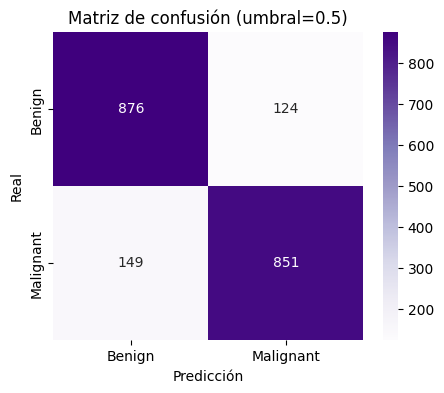

In [18]:
umbral = 0.5
y_pred_class = (y_pred_prob[:, 1] >= umbral).astype(int)

cm = confusion_matrix(y_true, y_pred_class)

labels = list(test_gen.class_indices.keys())
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f"Matriz de confusión (umbral={umbral})")
plt.show()

In [19]:
labels = list(test_gen.class_indices.keys())
print("Orden de clases:", test_gen.class_indices)

# Generar el reporte automático
print(classification_report(y_true, y_pred_class, target_names=labels, digits=3))

Orden de clases: {'Benign': 0, 'Malignant': 1}
              precision    recall  f1-score   support

      Benign      0.855     0.876     0.865      1000
   Malignant      0.873     0.851     0.862      1000

    accuracy                          0.864      2000
   macro avg      0.864     0.863     0.863      2000
weighted avg      0.864     0.864     0.863      2000



## Imágenes Externas

In [20]:
external_dir = "../data/lesions/external"
ROWS, COLS = 224, 224
BATCH = 1  # una imagen por lote para visualizar fácilmente

ext_datagen = ImageDataGenerator(rescale=1./255)

ext_gen = ext_datagen.flow_from_directory(
    directory=external_dir,
    target_size=(ROWS, COLS),
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

Found 45 images belonging to 2 classes.


In [21]:
# Probabilidades y clases
pred_probs = modelo1.predict(ext_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = ext_gen.classes
labels = list(ext_gen.class_indices.keys())

45/45 [==============================] - 0s 2ms/step


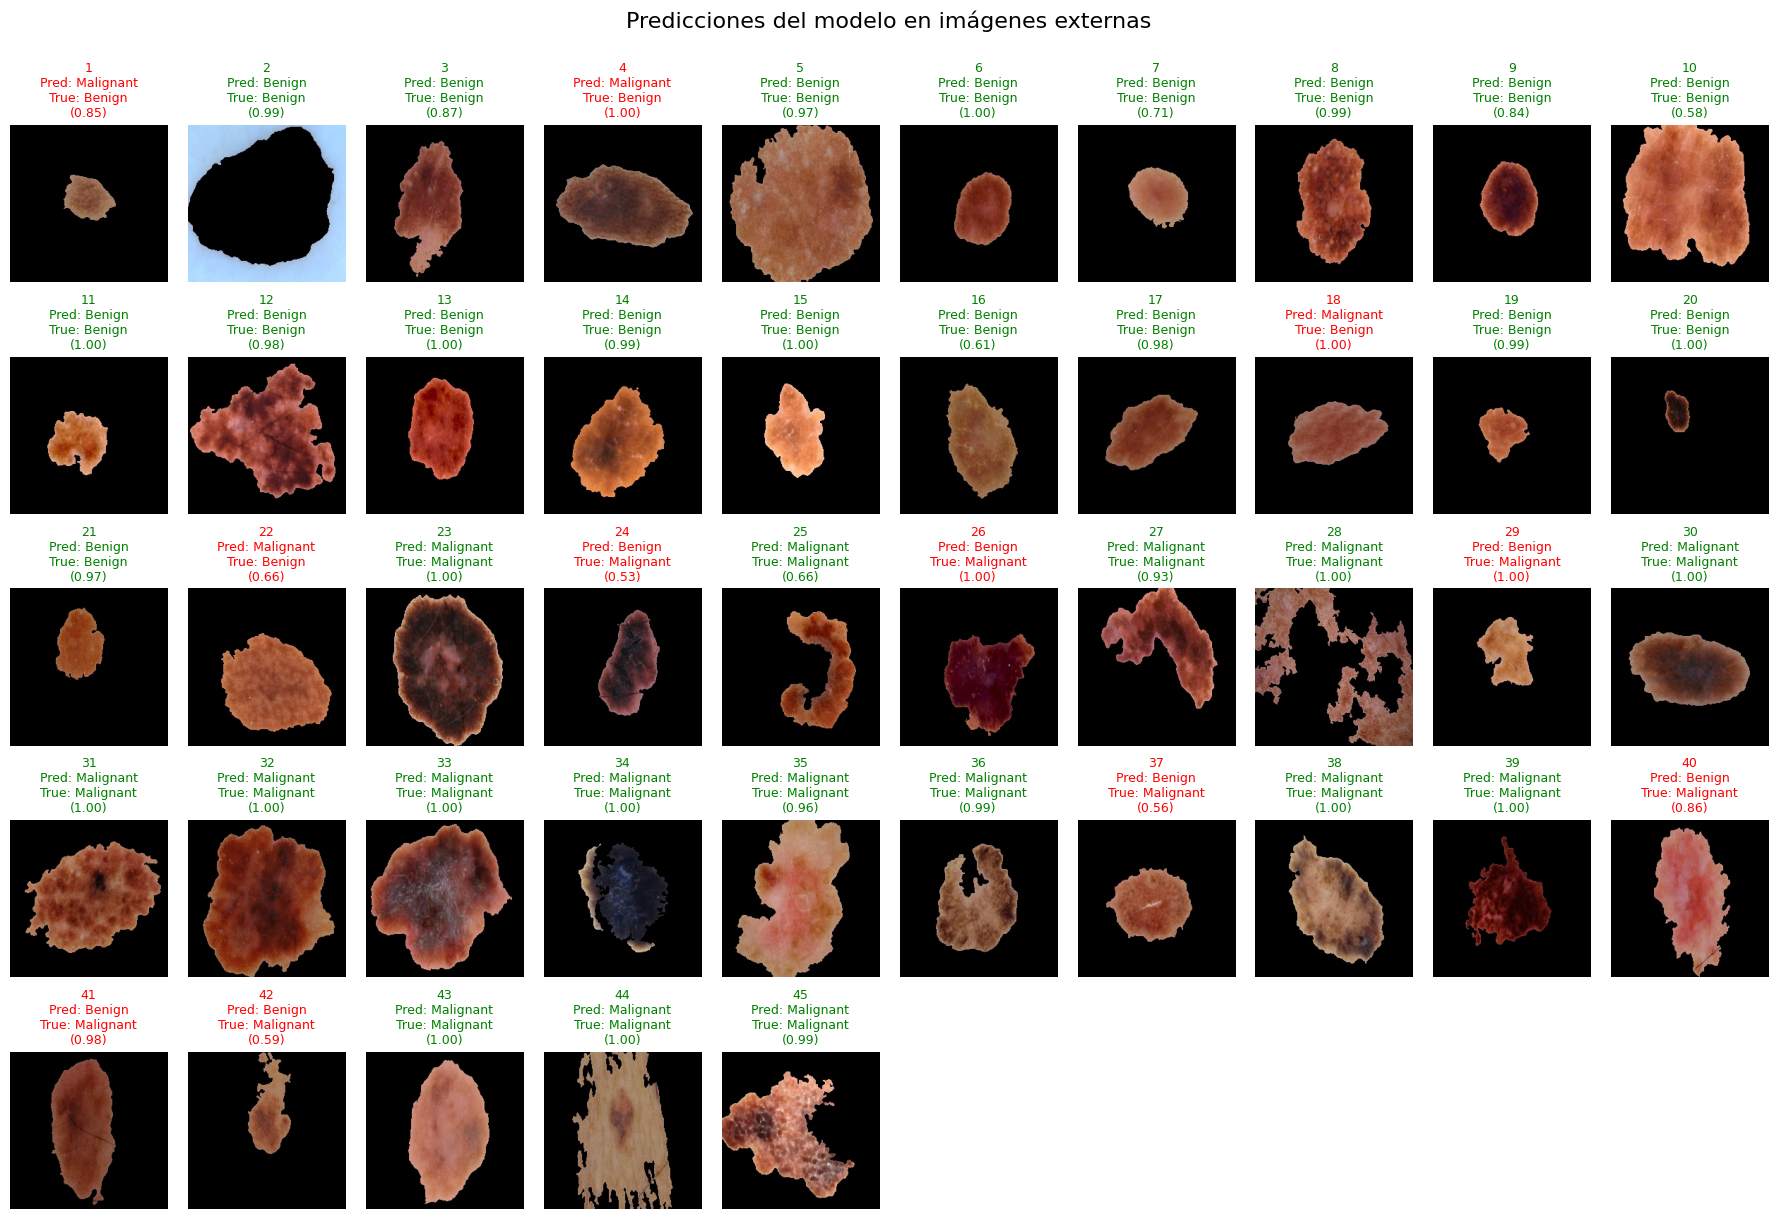

In [22]:
N = ext_gen.filenames.__len__()
rows, cols = 5, 10

plt.figure(figsize=(18, 12))

for i in range(N):
    img, _ = ext_gen[i]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img[0])

    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones del modelo en imágenes externas", fontsize=16, y=1.03)
plt.show()

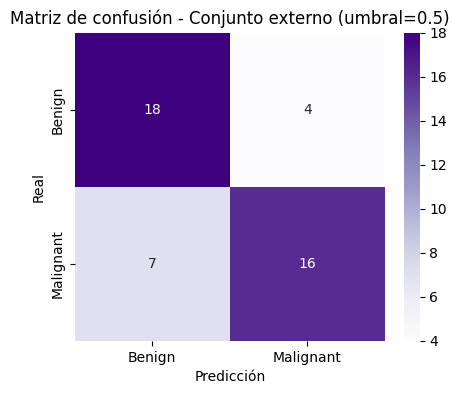

In [23]:
umbral = 0.5
y_pred_ext = (pred_probs[:, 1] >= umbral).astype(int)
y_true_ext = true_classes

# Calcular matriz de confusión
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)

# Mostrar con seaborn
plt.figure(figsize=(5,4))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - Conjunto externo (umbral={umbral})")
plt.show()

### Grad Cam

In [24]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

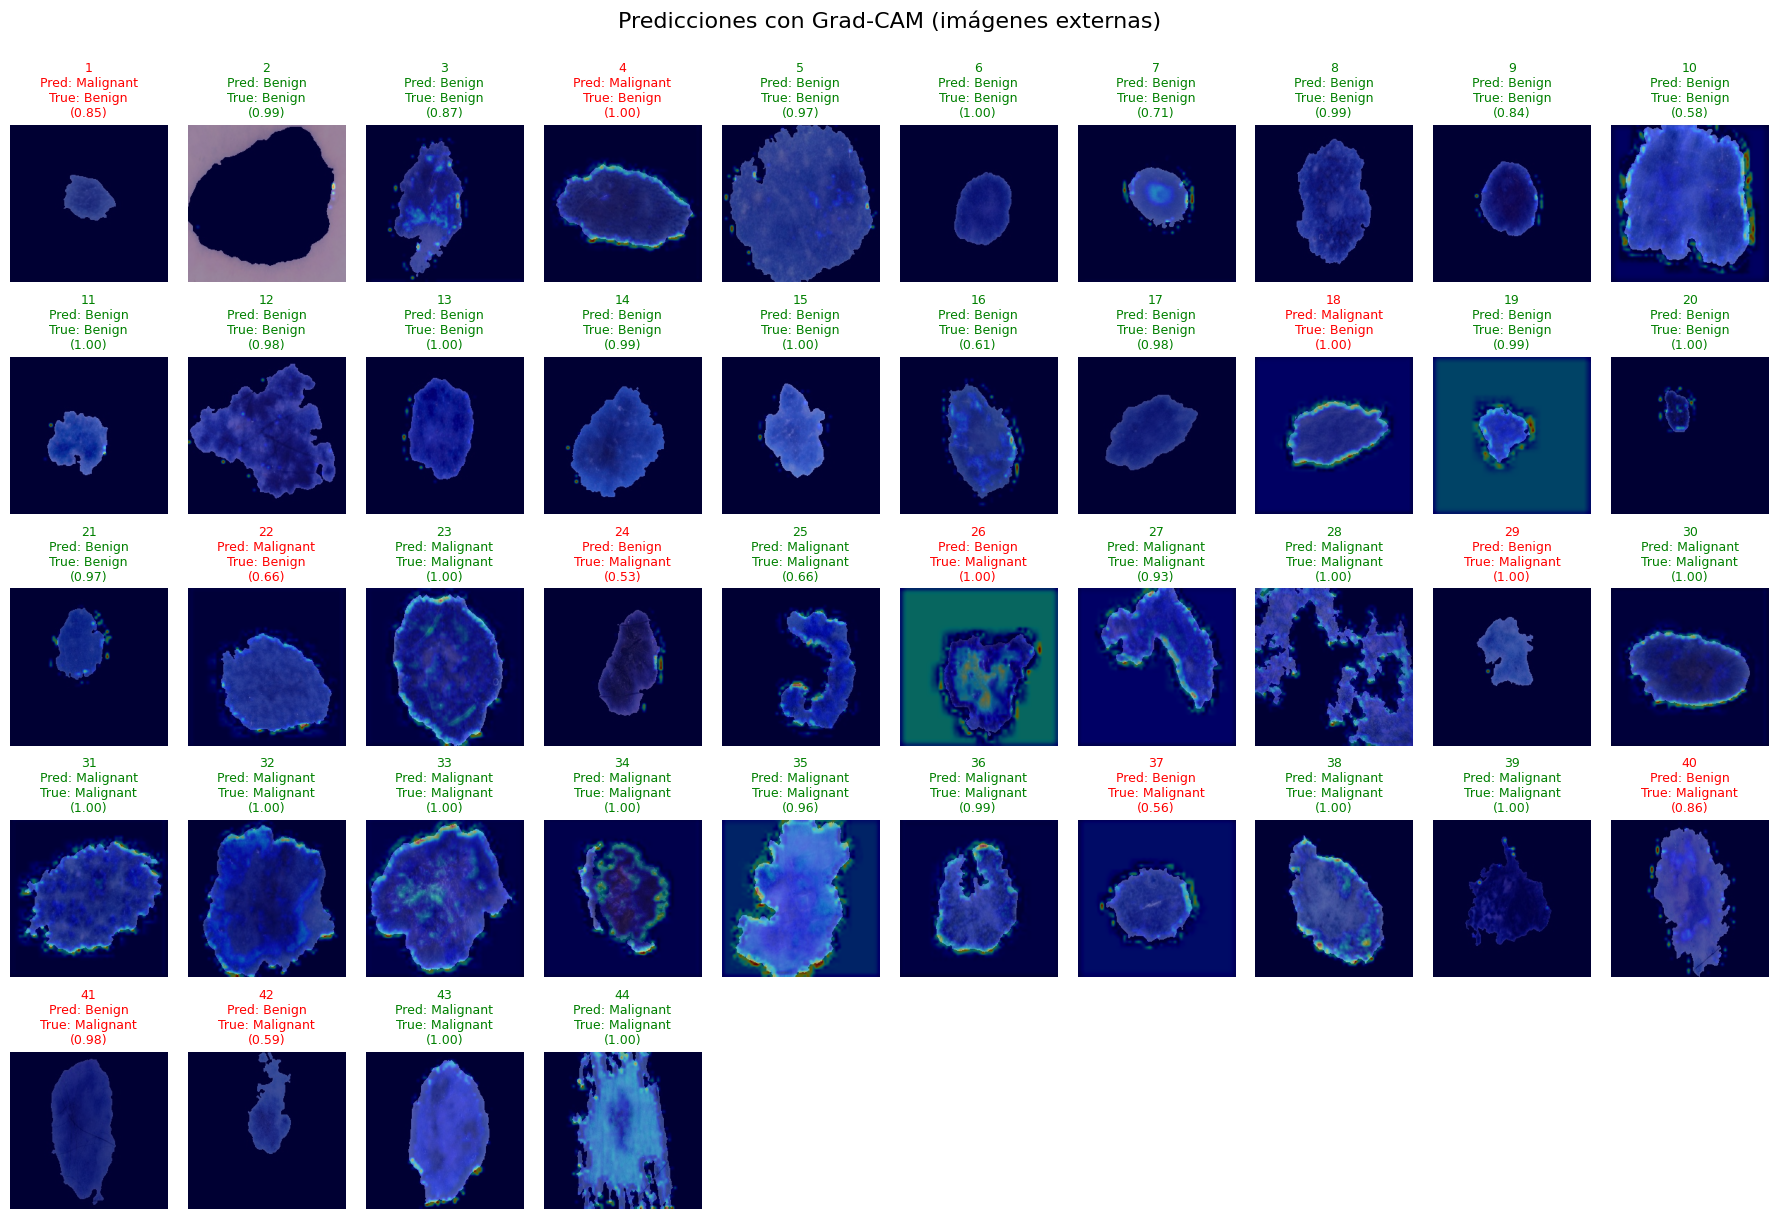

In [25]:
N = 44 # número de imágenes a mostrar
rows, cols = 5, 10
plt.figure(figsize=(18, 12))

# --- Bucle principal ---
for i in range(N):
    img, _ = ext_gen[i]
    img_sample = img[0]
    img_array = np.expand_dims(img_sample, axis=0)

    # Grad-CAM sobre la última capa convolucional
    heatmap = make_gradcam_heatmap(img_array, modelo1, "conv3")

    # Redimensionar y superponer
    heatmap = cv2.resize(heatmap, (ROWS, COLS))
    heatmap_color = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_color, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted((img_sample * 255).astype("uint8"), 0.6, heatmap_color, 0.4, 0)

    # --- Predicción y etiqueta ---
    true_label = labels[true_classes[i]]
    pred_label = labels[pred_classes[i]]
    prob = pred_probs[i][pred_classes[i]]

    # --- Mostrar resultado ---
    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    color = "green" if true_label == pred_label else "red"
    plt.title(f"{i+1}\nPred: {pred_label}\nTrue: {true_label}\n({prob:.2f})", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout(pad=1.5)
plt.suptitle("Predicciones con Grad-CAM (imágenes externas)", fontsize=16, y=1.03)
plt.show()

# Procesamiento Modelo

In [26]:
modelo1.summary()

Model: "MelanomaNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2 (Conv2D)              (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     

In [28]:
modelo1.save("MelanomaNet.keras")
modelo1.save("MelanomaNet.h5")